# Feature Selection
This notebook goes over the decision-making process for selecting features from the NASA exoplanet dataset. <br>
We split features into planetary, stellar and system features for ease of analysis.

## Initial Selection Criteria
Features are first filtered out based on a few basic rules:
- We check features for completeness and discard those with a missingness greater than 25%. 
- Features with a missingness in the 20-25% range are evaluated for retention based on correlation with the target variable (planetary mass).
- Columns containing metadata (references, limits, controversial flags, errors and notes) are discarded.
- Columns encoding redundant information are dropped - like planet radius in units of Jupiter radii and Earth radii.
- Observer dependent features such as apparent magnitudes, parallax and relative motion are excluded as they reflect observational geometry.

A missingness threshold of 20% balances feature richness and imputation reliability. This is also motivated by the systematic differences in the data as features with higher missingness tend to lack data entirely for certain discovery methods. We also want to avoid models learning from imputation artifacts. 

Features in the 20-25% borderline range were evaluated individually to permit retention of highly informative features.

## Follow up steps
Once the initial missingness sweep is done, we further analyse the preliminary set of features.
- A skewness check is done to confirm our need for spearman correlations.
- Spearman correlation is calculated between preliminary features and the target (planet mass) to evaluate their informativeness.
- Spearman correlation is also calculated between each pair of preliminary features to avoid multicollinearity.
- Statistical and Physical considerations are made when deciding which preliminary features to discard when facing high multicollinearity.

In [75]:
# Set root folder context
import os
import sys
from pathlib import Path
if not hasattr(sys,"_project_root_initialized"):
    PROJECT_ROOT = Path.cwd().parent
    sys.path.insert(0, str(PROJECT_ROOT))
    os.chdir(PROJECT_ROOT)
    sys._project_root_initialized = True

In [76]:
# Imports
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [77]:
# Local Imports
from src.utils import print_data_summary
from src.data_processing import load_exoplanet_data

In [78]:
# Load Exoplanet Data
# Original file can be found at https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PSCompPars
planets=load_exoplanet_data()
target="pl_bmasse"

In [79]:
def make_filter(startswith_exclude=None, endswith_exclude=None, contains_exclude=None):
    def f(col):
        if startswith_exclude and any(col.startswith(s) for s in startswith_exclude):
            return False
        if endswith_exclude and any(col.endswith(e) for e in endswith_exclude):
            return False
        if contains_exclude and any(ex in col for ex in contains_exclude):
            return False
        return True
    return f

MISSINGNESS_THRESHOLD = 0.2
BORDERLINE_THRESHOLD=0.25

## Planetary features
- We ignore planet density as it is directly linked to planet mass and radius.
- Angular separation is dropped as it is an observational artifact.

Hence, our main candidate planetary features are `pl_orbeccen`,`pl_orbper`,`pl_orbsmax` and `pl_rade`

In [80]:
# Check missingness for all planet features
pl_filter=make_filter(
    endswith_exclude=['_reflink','lim','notes','name','letter','flag','j','ntranspec','nespec','ndispec','ref'],
    contains_exclude=['err','mass']
)
pl_features = [col for col in planets.columns if col.startswith('pl_') and pl_filter(col)]
missing_all = planets[pl_features].isna().mean().sort_values(ascending=False)
main_candidates=missing_all[missing_all < MISSINGNESS_THRESHOLD]
borderline=missing_all[(missing_all >= MISSINGNESS_THRESHOLD) & (missing_all < BORDERLINE_THRESHOLD)]
print("Main candidates:")
print(main_candidates.to_string())

Main candidates:
pl_orbeccen    0.149571
pl_angsep      0.056069
pl_orbper      0.052770
pl_orbsmax     0.051286
pl_dens        0.017810
pl_rade        0.007091


We discard both our borderline features because:
- Despite having a moderate correlation, `pl_tranmid` is an observational artifact of the transit detection process rather than an intrinsic property of the planet.
- `pl_orbincl` is excluded due to its low correlation and high missingness.

In [81]:
borderline_features = borderline.index.tolist()

borderline_summary = pd.DataFrame({
    'missingness': planets[borderline_features].isna().mean(),
    'spearman_corr': [planets[[col, target]].corr(method='spearman').loc[col, target] 
                      for col in borderline_features]
}).sort_values('spearman_corr', key=abs, ascending=False)

print(borderline_summary)

            missingness  spearman_corr
pl_tranmid     0.203496       0.367209
pl_orbincl     0.245712      -0.098580


### Preliminary Planetary Features

In [82]:
pl_features=['pl_orbeccen','pl_orbsmax','pl_orbper','pl_rade']

#### Skewness Analysis

Skewness analysis reveals that all candidate features have skew>1, with orbital period being the most extreme, reflecting strong detection bias for short-period planets.

Despite being bounded to [0,1], `pl_orbeccen` shows notable skew, consistent with the tendency of detected exoplanets towards near-circular orbits. 

In [83]:
corr_features=pl_features+[target]
corr_df=planets[corr_features].copy()
print(corr_df[pl_features].skew().sort_values(ascending=False).to_string())

pl_orbper      75.681673
pl_orbsmax     39.134352
pl_orbeccen     2.634729
pl_rade         1.783035


To minimize the effect of skewness on correlations, we utilize spearman correlation and perform log-transformation of all fields before calculating pearson coefficients.

Spearman correlation is used as the primary ranking metric, given the non-linear nature of the data.

#### Spearman Correlation

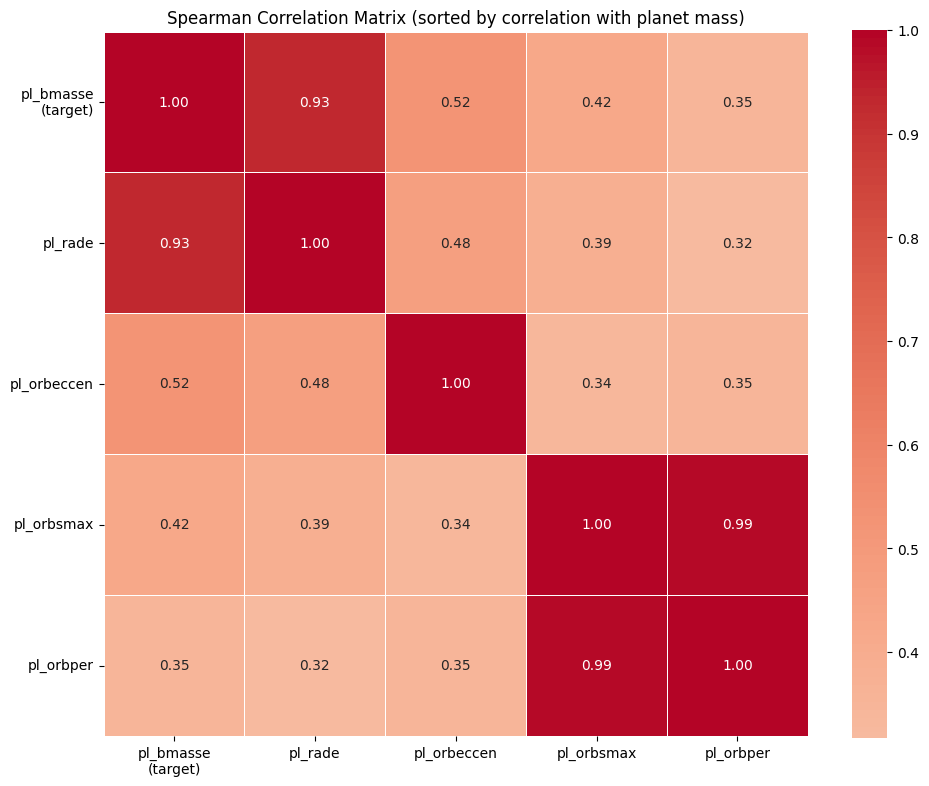

In [84]:
# Sort features by absolute Spearman correlation with target
spearman_corr = corr_df.corr(method='spearman')
target_corr_order = spearman_corr[target].abs().sort_values(ascending=False).index
spearman_corr_sorted = spearman_corr.loc[target_corr_order, target_corr_order]

# Rename target label
label_map = {target: f'{target}\n(target)'}
spearman_corr_sorted = spearman_corr_sorted.rename(index=label_map, columns=label_map)

plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr_sorted,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    xticklabels=True
)
plt.title("Spearman Correlation Matrix (sorted by correlation with planet mass)")
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0 )
plt.tight_layout()
plt.show()

#### Key Observations
- `pl_rade` shows the strongest correlation with mass (r=0.93), reflecting the well-established mass-radius relationship. 
- `pl_orbeccen` shows a moderate correlation (r=0.52) consistent with more massive planets having dynamic orbits.
- `pl_orbsmax` and `pl_orbper` show near-perfect inter-feature correlation (r=0.99). This is a direct consequence of Keplers law ($T^2 \propto a^3$). Retaining both would introduce sever multicollinearity, hence we drop `pl_orbper` in favor of `pl_orbsmax` as the more physically direct quantity and the more complete feature.

### Final Planetary Features

In [85]:
pl_features=['pl_orbeccen','pl_orbsmax','pl_rade']

## Stellar Features
- `st_met` (stellar metallicity) is included as a single feature despite mixing Fe/H and M/H measurement conventions as these scales are closely correlated across most stellar populations. The distinction is unlikely to affect predictions, but it nonetheless presents a minor source of measurement heterogeneity.
- `st_dens` (stellar density) is directly dependent on stellar mass and stellar radius. Since it is not needed to impute any of the missing values, it can be dropped.

In [86]:
# Check missingness for all stellar features
st_filter=make_filter(
    endswith_exclude=['_reflink','lim','nphot','nrvc','nspec'],
    contains_exclude=['err','metratio']
)
st_features = [col for col in planets.columns if col.startswith('st_') and st_filter(col)]
missing_all = planets[st_features].isna().mean().sort_values(ascending=False)
main_candidates=missing_all[missing_all < MISSINGNESS_THRESHOLD]
borderline=missing_all[(missing_all >= MISSINGNESS_THRESHOLD) & (missing_all < BORDERLINE_THRESHOLD)]
print("Main candidates:")
print(main_candidates.to_string())

Main candidates:
st_dens    0.095811
st_met     0.090699
st_logg    0.052441
st_rad     0.051781
st_lum     0.050792
st_teff    0.047823
st_mass    0.002803


In [87]:
mask = planets['st_mass'].isna() & planets['st_dens'].notna() & planets['st_rad'].notna()
print(f"Cases where imputation is possible: {mask.sum()}")

Cases where imputation is possible: 0


`st_age` (stellar age) is discarded as it falls in the borderline missing range (21%) and it shows weak correlation with the target, suggesting limited predictive value.

In [88]:
borderline_st_features = borderline.index.tolist()

borderline_st_summary = pd.DataFrame({
    'missingness': planets[borderline_st_features].isna().mean(),
    'spearman_corr': [planets[[col, target]].corr(method='spearman').loc[col, target] 
                      for col in borderline_st_features]
}).sort_values('spearman_corr', key=abs, ascending=False)

print(borderline_st_summary)

        missingness  spearman_corr
st_age     0.213226      -0.069313


### Preliminary Stellar Features

In [89]:
st_features=['st_mass','st_rad','st_logg','st_met','st_lum','st_teff']

#### Skewness Analysis

In [90]:
corr_features=st_features+[target]
corr_df=planets[corr_features].copy()
print(corr_df[st_features].skew().sort_values(ascending=False).to_string())

st_rad     13.131285
st_teff    10.883094
st_mass     6.214679
st_lum     -0.473434
st_met     -0.562981
st_logg    -2.824107


#### Spearman Correlation

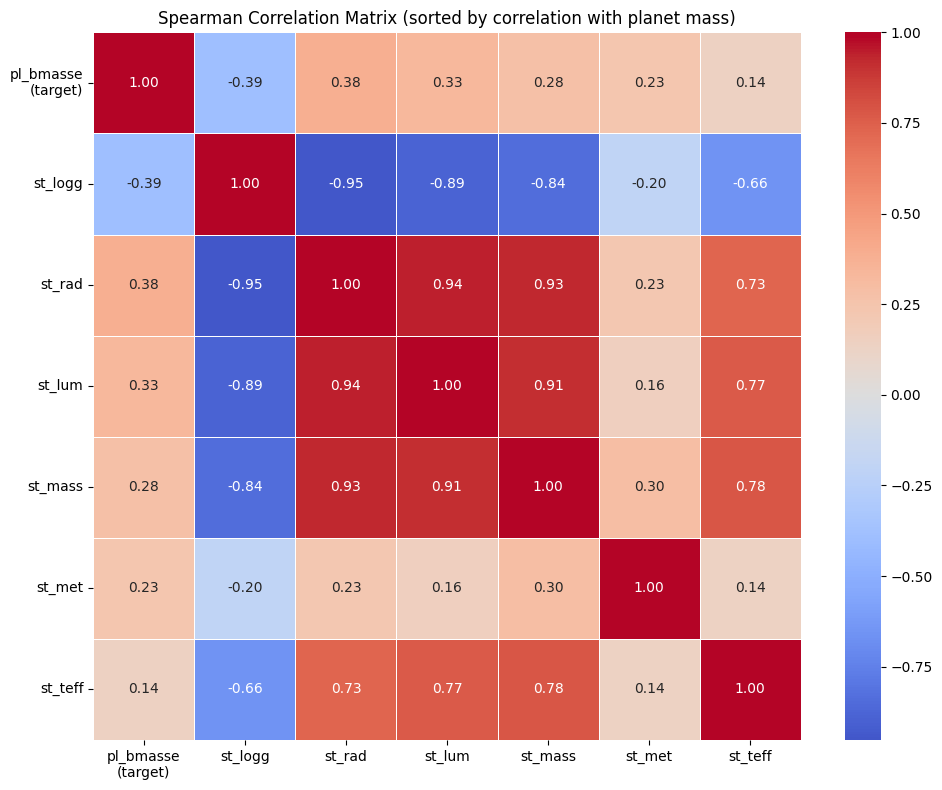

In [91]:
# Sort features by absolute Spearman correlation with target
spearman_corr = corr_df.corr(method='spearman')
target_corr_order = spearman_corr[target].abs().sort_values(ascending=False).index
spearman_corr_sorted = spearman_corr.loc[target_corr_order, target_corr_order]

# Rename target label
label_map = {target: f'{target}\n(target)'}
spearman_corr_sorted = spearman_corr_sorted.rename(index=label_map, columns=label_map)

plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr_sorted,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    xticklabels=True
)
plt.title("Spearman Correlation Matrix (sorted by correlation with planet mass)")
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0 )
plt.tight_layout()
plt.show()

#### Key Observations
- Stellar features show moderate correlations with planet mass, with `st_logg` (r=-0.39) and `st_rad` (r=0.38) being the strongest predictors. This reflects that stars with lower surface gravity (typically larger, more mature stars) tend to host more massive planets.
- `st_logg`,`st_rad`,`st_lum` and `st_mass` are all heavily intercorrelated, forming a multicollinearity cluster (pairwise r:0.84-0.95). This is physically expected as all four qualities are fundamentally interdependent. Larger, more massive stars tend to have higher luminosity ($L \propto R^2$) and lower surface gravity ($g \propto M/R^2$). <br>
`st_rad` is retained as the sole representative as it`s a directly observable quantity with the strongest correlation among the non-derived features along with having a sufficiently low correlation with `st_teff`. 
- `st_met` and `st_teff` are retained as they carry relatively independent signals from the rest of the cluster, with `st_met` being particularly independent.
- `st_teff` shows the weakest direct correlation with planet mass (r=0.14) but is retained as it encodes stellar type information that may still interact meaningfully with other features.

### Final Stellar Features

In [92]:
st_features=['st_rad','st_met','st_teff']

## System Features
- Most system features would bear no physical connection to planet mass. For example, `sy_plx` and magnitude features in the format `sy_*mag` are all observer and distance dependent. Similarly,`sy_pm`, `sy_pmra`, and `sy_pmdec` describe stellar kinematics, no physical connection to planet mass.
- `sy_mnum` (moon count) is dropped as it's 0 for all data points.
- This leaves us with `sy_snum` (number of stars), and `sy_pnum` (number of planets) in the system.

In [93]:
# Check missingness for all system features
sy_filter=make_filter(
    endswith_exclude=['_reflink','lim','notes','letter','flag','j','ntranspec','nespec','ndispec','ref','mag','plx','dist'],
    contains_exclude=['err','pm']
)
sy_features = [col for col in planets.columns if col.startswith('sy_') and sy_filter(col)]
missing_all = planets[sy_features].isna().mean().sort_values(ascending=False)
main_candidates=missing_all[missing_all < MISSINGNESS_THRESHOLD]
borderline=missing_all[(missing_all >= MISSINGNESS_THRESHOLD) & (missing_all < BORDERLINE_THRESHOLD)]
print("Main candidates:")
print(main_candidates.to_string())
print("\nBorderline candidates:")
print(borderline.to_string())

Main candidates:
sy_snum    0.0
sy_pnum    0.0
sy_mnum    0.0

Borderline candidates:
Series([], )


In [94]:
for feature in ['sy_snum', 'sy_pnum', 'sy_mnum']:
    print(planets[feature].value_counts().sort_index().to_string())

sy_snum
1    5511
2     482
3      70
4       1
sy_pnum
1    3486
2    1381
3     639
4     324
5     140
6      72
7      14
8       8
sy_mnum
0    6064


### Preliminary System Features

In [95]:
sy_features=['sy_snum','sy_pnum']

#### Skewness Analysis

In [96]:
corr_features=sy_features+[target]
corr_df=planets[corr_features].copy()
print(corr_df[sy_features].skew().sort_values(ascending=False).to_string())

sy_snum    3.499653
sy_pnum    1.820038


#### Spearman Correlation

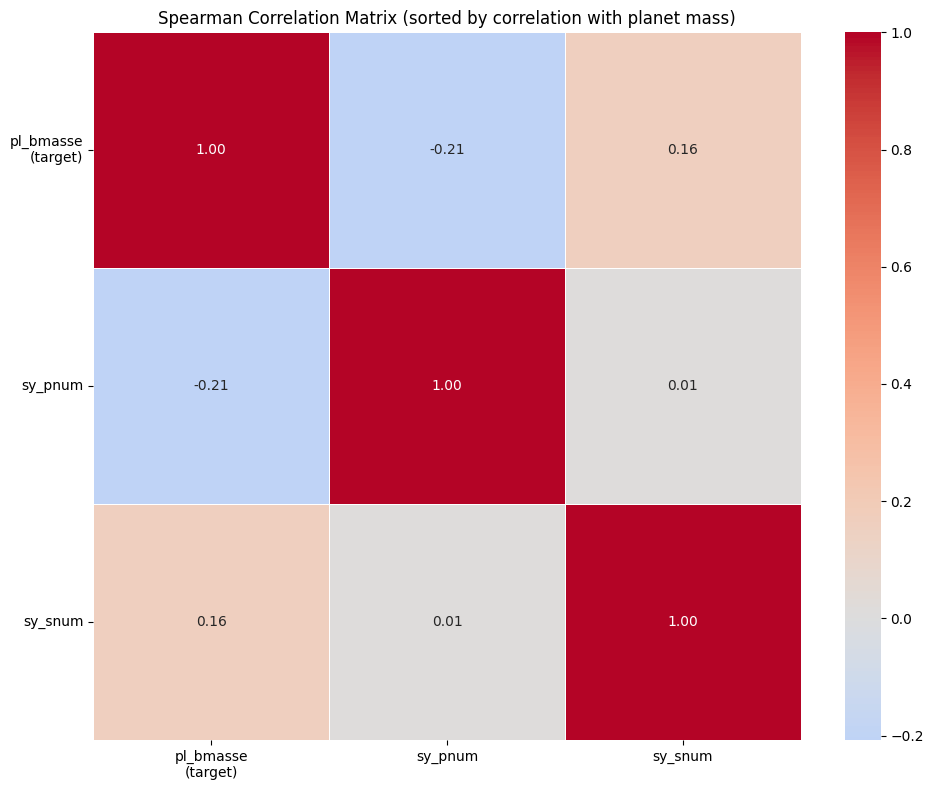

In [97]:
# Sort features by absolute Spearman correlation with target
spearman_corr = corr_df.corr(method='spearman')
target_corr_order = spearman_corr[target].abs().sort_values(ascending=False).index
spearman_corr_sorted = spearman_corr.loc[target_corr_order, target_corr_order]

# Rename target label
label_map = {target: f'{target}\n(target)'}
spearman_corr_sorted = spearman_corr_sorted.rename(index=label_map, columns=label_map)

plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr_sorted,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    xticklabels=True
)
plt.title("Spearman Correlation Matrix (sorted by correlation with planet mass)")
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0 )
plt.tight_layout()
plt.show()

#### Key Observations

- `sy_pnum` shows a weak negative correlation with the target (r=-0.21), consistent with multi-planet systems tending to host smaller planets rather than a small number of massive planets.
- `sy_snum` shows a weak positive correlation (r=0.16), potentially reflecting gravitational influences of multi-star systems on planet formation.
- Both features are mutually independent with no multicollinearity concerns.

### Final System Features

In [99]:
sy_features=['sy_snum','sy_pnum']

## Final Feature Set

Based on missingness thresholds, correlation analysis, and multicollinearity checks, 
the following features are selected:

### Planetary
- `pl_rade` — planet radius (Earth radii)
- `pl_orbeccen` — orbital eccentricity
- `pl_orbsmax` — semi-major axis (AU)

### Stellar
- `st_rad` — stellar radius (Solar radii)
- `st_teff` — stellar effective temperature (K)
- `st_met` — stellar metallicity

### System
- `sy_pnum` — number of planets in system
- `sy_snum` — number of stars in system

In [100]:
final_features = pl_features + st_features + sy_features
print("Final selected features:")
print(final_features)

Final selected features:
['pl_orbeccen', 'pl_orbsmax', 'pl_rade', 'st_rad', 'st_met', 'st_teff', 'sy_snum', 'sy_pnum']


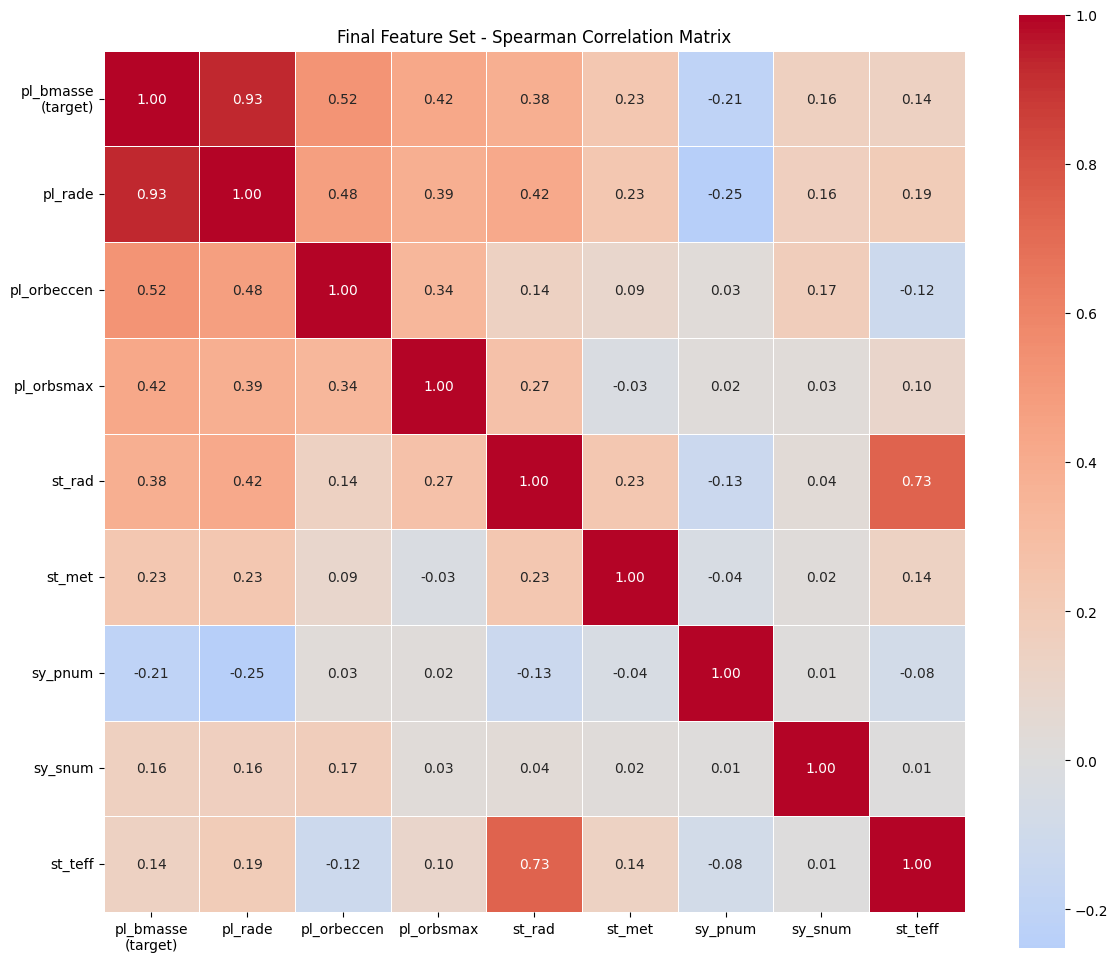

In [101]:
final_corr = planets[final_features + [target]].corr(method='spearman')
target_order = final_corr[target].abs().sort_values(ascending=False).index
final_corr_sorted = final_corr.loc[target_order, target_order]

label_map = {target: f'{target}\n(target)'}
final_corr_sorted = final_corr_sorted.rename(index=label_map, columns=label_map)

plt.figure(figsize=(12, 10))
sns.heatmap(
    final_corr_sorted,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    xticklabels=final_corr_sorted.columns.tolist(),
    yticklabels=final_corr_sorted.columns.tolist()
)
plt.title("Final Feature Set - Spearman Correlation Matrix")
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Pearson vs Spearman Comparison
Overall the two metrics are broadly consistent, with a few notable observations:

- `pl_rade` shows strong agreement between both metrics (difference: 0.02), confirming 
the mass-radius relationship is well-behaved and linear in log-space.

- `pl_orbsmax` shows the largest divergence (difference: 0.10), with Pearson notably 
higher than Spearman. This suggests residual non-linearity even after log-transformation, 
likely driven by detection bias toward short-period, close-in planets.

- `st_met` shows moderate divergence (difference: 0.05) in the opposite direction,
Spearman higher than Pearson, suggesting the metallicity-mass relationship is better 
captured as a monotonic ranking than a linear one.

- `st_rad` shows moderate divergence (difference: 0.05), consistent with the known 
non-linear nature of stellar structure relationships.

These divergences reinforce the use of Spearman as the primary correlation metric. It also suggests that we should explore tree-based models to capture these non-linear relationships.

In [103]:
# Pearson on log-transformed data
final_log_df = planets[final_features + [target]].copy()
for col in final_features + [target]:
    if planets[col].skew() > 1:
        final_log_df[col] = np.log1p(final_log_df[col])

pearson_target = final_log_df.corr(method='pearson')[target].drop(target)
spearman_target = planets[final_features + [target]].corr(method='spearman')[target].drop(target)

comparison_df = pd.DataFrame({
    'Spearman': spearman_target,
    'Pearson': pearson_target,
    'Difference': (pearson_target - spearman_target).abs()
}).sort_values('Spearman', key=abs, ascending=False)

print(comparison_df.to_string())

             Spearman   Pearson  Difference
pl_rade      0.930516  0.914499    0.016018
pl_orbeccen  0.524150  0.497409    0.026742
pl_orbsmax   0.424366  0.521624    0.097258
st_rad       0.384717  0.433528    0.048811
st_met       0.231931  0.181723    0.050209
sy_pnum     -0.207570 -0.217226    0.009655
sy_snum      0.157388  0.170724    0.013335
st_teff      0.141093  0.124646    0.016447
